## Step 1: Import common Python packages

In [1]:
import os
import openpyxl
import pandas as pd
import numpy as np

## Step 2: Setup working directory

In [2]:
os.chdir('/Users/markruperto/Desktop/School/GCU/BIT-456/Topic 1 - XGBoost')

In [3]:
os.getcwd()

'/Users/markruperto/Desktop/School/GCU/BIT-456/Topic 1 - XGBoost'

## Step 3: Import data

In [4]:
weeklydata = pd.read_excel('weeklydata.xlsx')

weeklydata.head()

,Minute,shampoo,conditioner,toothpaste,barsoap,liquidsoap,bodywash,deodorant,shavingcream,facialcream,mouthwash,satisfaction
0,0,868.04,731.27,811.74,731.01,870.10,612.38,786.60,899.06,699.12,778.03,1
1,1,618.25,901.00,684.83,871.58,781.81,661.20,931.70,695.72,811.75,801.38,1
2,2,665.00,688.88,541.34,913.33,702.66,771.87,716.25,857.51,844.38,751.22,1
3,3,737.27,943.11,666.09,743.66,940.58,556.77,736.14,847.92,684.88,776.62,1
4,4,578.61,1067.61,732.73,717.00,555.63,576.21,758.60,990.53,907.65,723.32,1


## Step 4: Determine the counts for each category of the "satisfaction" variable

In [5]:
weeklydata['satisfaction'].value_counts(dropna=False)

satisfaction
1    8881
0    1119
Name: count, dtype: int64

## Step 5: Define weeklydata to specify the features and the target variable

In [6]:
feature_columns = ['shampoo', 'conditioner', 'toothpaste', 'barsoap', 'liquidsoap',
                   'bodywash', 'deodorant', 'shavingcream', 'facialcream', 'mouthwash']

x = weeklydata[feature_columns]
y = weeklydata.satisfaction

print(feature_columns)

['shampoo', 'conditioner', 'toothpaste', 'barsoap', 'liquidsoap', 'bodywash', 'deodorant', 'shavingcream', 'facialcream', 'mouthwash']


## Step 6: X and Y into training and testing sets (80/20) split

In [7]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Step 7: Create an XGBoost Classifier

In [8]:
import xgboost as xgb

model = xgb.XGBClassifier() #creates the classifier with all default hyperparameters

## Step 8: Train the model using the training data using "xgboost" package

In [9]:
model.fit(x_train, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


## Step 9: Perform cross-validation on training dataset

In [29]:
from sklearn.model_selection import KFold
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score

kfold = KFold(n_splits=5) #splits data into 5 equal folds
cv_results = cross_val_score(model, x_train, y_train, cv=kfold, scoring='accuracy') #handles scoring and fitting

print("Cross-validation accuracy:", cv_results)
print("Mean accuracy:", cv_results.mean())

Cross-validation accuracy: [0.945    0.949375 0.935    0.945625 0.941875]
Mean accuracy: 0.943375


## Step 10: Plot the feature importance

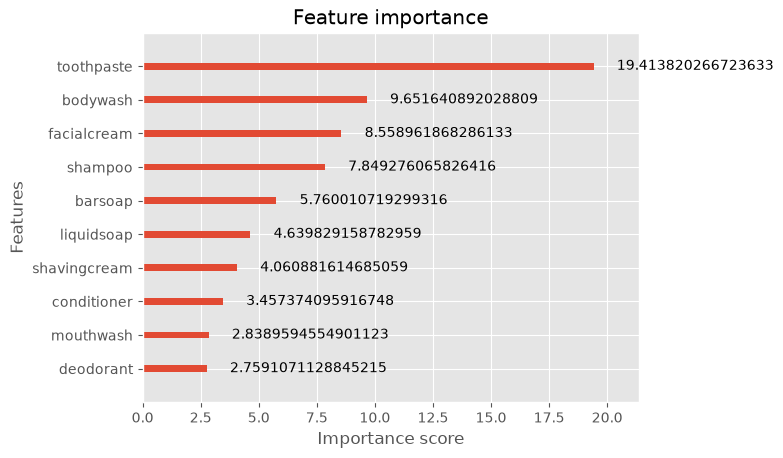

In [33]:
from xgboost import plot_importance
from matplotlib import pyplot as plt
#produces a horizontal bar chart showing each feature ranked by its importance score

plot_importance(model, importance_type='gain')
plt.show()

## Step 11: Obtain most important features of the model

In [31]:
feature_scores = pd.Series(model.feature_importances_, index=x_train.columns).sort_values(ascending=False)
print("Most Important Features")
print(feature_scores)

Most Important Features
toothpaste      0.281401
bodywash        0.139899
facialcream     0.124061
shampoo         0.113774
barsoap         0.083491
liquidsoap      0.067254
shavingcream    0.058862
conditioner     0.050114
mouthwash       0.041150
deodorant       0.039993
dtype: float32


## Step 12: Predict responses for test data

In [24]:
y_pred = model.predict(x_test)

## Step 13: Create a confusion matrix for the model

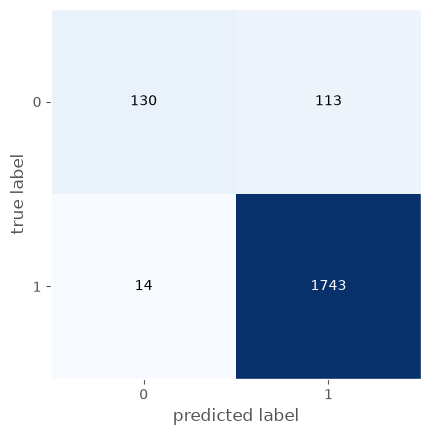

In [25]:
from sklearn.metrics import confusion_matrix
from mlxtend.plotting import plot_confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred) #compares actual test labels against the model's predictions and builds the matrix
fig, ax = plot_confusion_matrix(conf_mat=cm) #renders the matrix as a labeled, color-coded heatmap
plt.show()

## Step 14: Visualizations using kds package

LABELS INFO:

 prob_min         : Minimum probability in a particular decile
 prob_max         : Minimum probability in a particular decile
 prob_avg         : Average probability in a particular decile
 cnt_events       : Count of events in a particular decile
 cnt_resp         : Count of responders in a particular decile
 cnt_non_resp     : Count of non-responders in a particular decile
 cnt_resp_rndm    : Count of responders if events assigned randomly in a particular decile
 cnt_resp_wiz     : Count of best possible responders in a particular decile
 resp_rate        : Response Rate in a particular decile [(cnt_resp/cnt_cust)*100]
 cum_events       : Cumulative sum of events decile-wise 
 cum_resp         : Cumulative sum of responders decile-wise 
 cum_resp_wiz     : Cumulative sum of best possible responders decile-wise 
 cum_non_resp     : Cumulative sum of non-responders decile-wise 
 cum_events_pct   : Cumulative sum of percentages of events decile-wise 
 cum_resp_pct     : Cu

/opt/anaconda3/lib/python3.13/site-packages/kds/metrics.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dt = df.groupby('decile').apply(lambda x: pd.Series([
/opt/anaconda3/lib/python3.13/site-packages/kds/metrics.py:85: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  dt = df.groupby('decile').apply(lambda x: pd.Series([
/opt/anaconda3/lib/python3.13/site-packages/kds/metrics.py:85: FutureWarning: DataFrameGroupBy

,decile,prob_min,prob_max,prob_avg,cnt_cust,cnt_resp,cnt_non_resp,cnt_resp_rndm,cnt_resp_wiz,resp_rate,cum_cust,cum_resp,cum_resp_wiz,cum_non_resp,cum_cust_pct,cum_resp_pct,cum_resp_pct_wiz,cum_non_resp_pct,KS,lift
0,1,0.998,1.000,0.999,200.0,187.0,13.0,175.7,200,93.5,200.0,187.0,200,13.0,10.0,10.643,11.383,5.350,5.293,1.064
1,2,0.996,0.998,0.997,200.0,191.0,9.0,175.7,200,95.5,400.0,378.0,400,22.0,20.0,21.514,22.766,9.053,12.461,1.076
2,3,0.993,0.996,0.994,200.0,188.0,12.0,175.7,200,94.0,600.0,566.0,600,34.0,30.0,32.214,34.149,13.992,18.222,1.074
3,4,0.990,0.993,0.991,200.0,190.0,10.0,175.7,200,95.0,800.0,756.0,800,44.0,40.0,43.028,45.532,18.107,24.921,1.076
4,5,0.985,0.990,0.987,200.0,189.0,11.0,175.7,200,94.5,1000.0,945.0,1000,55.0,50.0,53.785,56.915,22.634,31.151,1.076
5,6,0.977,0.985,0.981,200.0,187.0,13.0,175.7,200,93.5,1200.0,1132.0,1200,68.0,60.0,64.428,68.298,27.984,36.444,1.074
6,7,0.965,0.977,0.972,200.0,188.0,12.0,175.7,200,94.0,1400.0,1320.0,1400,80.0,70.0,75.128,79.681,32.922,42.206,1.073
7,8,0.943,0.965,0.956,200.0,189.0,11.0,175.7,200,94.5,1600.0,1509.0,1600,91.0,80.0,85.885,91.064,37.449,48.436,1.074
8,9,0.831,0.943,0.904,200.0,189.0,11.0,175.7,157,94.5,1800.0,1698.0,1757,102.0,90.0,96.642,100.000,41.975,54.667,1.074
9,10,0.001,0.828,0.263,200.0,59.0,141.0,175.7,0,29.5,2000.0,1757.0,1757,243.0,100.0,100.000,100.000,100.000,0.000,1.000


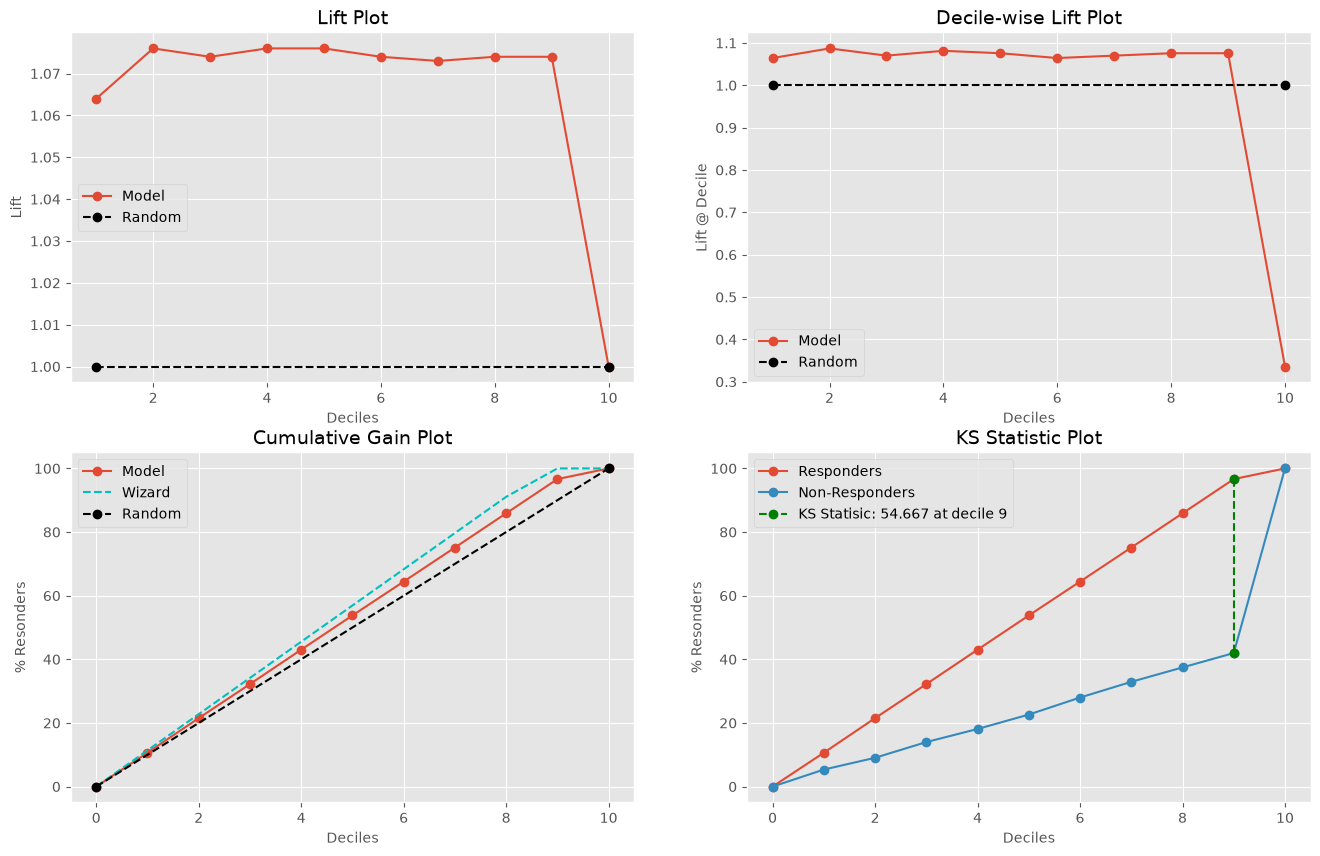

In [16]:
import kds
import matplotlib.pyplot as plt
plt.style.use('ggplot')

#kds needs probability of positive class
y_prob = model.predict_proba(x_test)[:, 1]

kds.metrics.report(y_test, y_prob)

## Step 15: Create an ROC (Receiver Operating Characteristic) chart

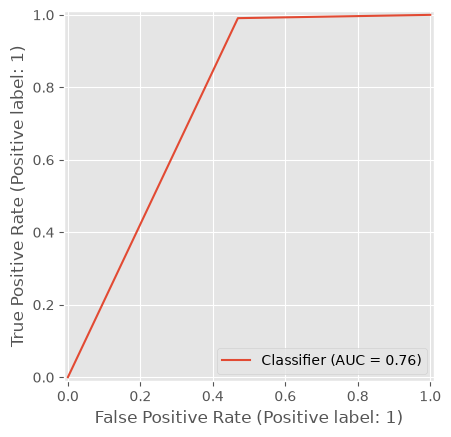

In [18]:
from sklearn.metrics import RocCurveDisplay

#This shows the tradeoff between the true positive rate and false positive rate 
#along with the AUC (Area Under the Curve) score
#the closer AUC is to 1.0, the better the model discriminates between classes.

RocCurveDisplay.from_predictions(y_test, y_pred)
plt.show()

## Step 16: Calculate comprehensive metrics for model using "from sklearn import metrics."

In [21]:
from sklearn import metrics

y_prob = model.predict_proba(x_test)[:, 1]

accuracy = metrics.accuracy_score(y_test, y_pred)
f1_macro = metrics.f1_score(y_test, y_pred, average='macro')
f1_micro = metrics.f1_score(y_test, y_pred, average='micro')
precision = metrics.precision_score(y_test, y_pred)
recall = metrics.recall_score(y_test, y_pred)
hamming = metrics.hamming_loss(y_test, y_pred)
jaccard = metrics.jaccard_score(y_test, y_pred)
logloss = metrics.log_loss(y_test, y_prob)
zero_one = metrics.zero_one_loss(y_test, y_pred)
roc_auc = metrics.roc_auc_score(y_test, y_prob)
mcc = metrics.matthews_corrcoef(y_test, y_pred)

print(f"Accuracy:              {accuracy:.4f}")
print(f"F1 Score (Macro):      {f1_macro:.4f}")
print(f"F1 Score (Micro):      {f1_micro:.4f}")
print(f"Precision Score:       {precision:.4f}")
print(f"Recall Score:          {recall:.4f}")
print(f"Hamming Loss:          {hamming:.4f}")
print(f"Jaccard Score:         {jaccard:.4f}")
print(f"Log Loss:              {logloss:.4f}")
print(f"Zero-One Loss:         {zero_one:.4f}")
print(f"ROC AUC Score:         {roc_auc:.4f}")
print(f"Matthews Corrcoef:     {mcc:.4f}")

Accuracy:              0.9350
F1 Score (Macro):      0.8145
F1 Score (Micro):      0.9350
Precision Score:       0.9385
Recall Score:          0.9909
Hamming Loss:          0.0650
Jaccard Score:         0.9305
Log Loss:              0.2881
Zero-One Loss:         0.0650
ROC AUC Score:         0.7818
Matthews Corrcoef:     0.6574


## Step 17: Observe model results and optimize key parameters to imrpove model performance

In [23]:
model = xgb.XGBClassifier(eta=0.08)
model.fit(x_train, y_train)
Y_pred = model.predict(x_test)

print("Accuracy:", metrics.accuracy_score(y_test, y_pred))
print("Precision:", metrics.precision_score(y_test, y_pred))

Accuracy: 0.935
Precision: 0.938544474393531


## Step 18: Conclusion

This project uses XGBoost, a machine learning algorithm that builds predictions by combining many decision trees to predict overall customer satisfaction with an online purchase experience, based on spending across ten product categories in the "weeklydata" dataset.

We began by defining the ten product features (shampoo, conditioner, toothpaste, bar soap, liquid soap, body wash, deodorant, shaving cream, facial cream, mouthwash) and the satisfaction target variable, then split the data into training (80%) and testing (20%) sets. The model was trained using the XGBoost classifier's default parameters. Cross-validation on the training data (5-fold) produced accuracy scores of 0.945, 0.949, 0.935, 0.946, and 0.942, with a mean cross-validation accuracy of 94.34%, indicating the model performs consistently well across different subsets of the training data.

Feature importance was examined two way. The plot from plot_importance() ranks features by how often they're used to split the data, while the printed feature importances from Step 11 rank features by how much each split actually improves predictions on average (a "gain" measure). By gain, toothpaste was the strongest predictor (28.1% of total importance), followed by body wash (14.0%) and facial cream (12.4%), while mouthwash (4.1%) and deodorant (4.0%) contributed the least. This tells us toothpaste-related splits are the most effective at separating satisfied from dissatisfied customers, even if it isn't necessarily the feature used most frequently across the trees.

On the test set, the model correctly predicted satisfaction status of 93.5% based on accuracy. When it predicted a customer was satisfied, it was correct 93.85% of the time which we based on the precision score., and it recall score shows it correctly identified 99.09% of all truly satisfied customers. 

The confusion matrix showed more false positives than false negatives, meaning the model occasionally predicted a customer was satisfied when they actually were not, more often than it missed a truly satisfied customer.

In practice, this model is a strong tool for identifying satisfied customers, but less reliable for flagging dissatisfaction. Toothpaste, body wash, and facial cream were the most influential predictors by gain, suggesting that oral care and personal hygiene spending patterns carry the most signal about customer satisfaction. Future refinements — such as addressing the class imbalance through class weighting or resampling — could help the model better detect the smaller group of dissatisfied customers and reduce false positives.